# 서울시 골목상권 폐업위험 조기경보
## EDA · 통계 분석 · 예측 모델링 정리

> 핵심 질문 — 다음 분기에 점포 순감소(폐업 > 개업)로 전환될 상권 × 업종은 어디이며, 무엇이 위험을 만드는가

본 문서는 분석 코드를 제외하고 **출력물과 판단만** 담음.


## 1. 분석 개요

서울시 상권 공공데이터를 사용해 요식업 점포의 폐업위험을 조기에 가려내는 것을 목적으로 함. 핵심 질문은 «다음 분기에 점포 순감소(폐업 > 개업)로 전환될 상권 × 업종은 어디이며, 무엇이 위험을 만드는가»임.

분석 단위는 상권 × 서비스업종 × 분기이며, 업종은 요식업 10종(한식음식점, 중식음식점, 일식음식점, 양식음식점, 제과점, 패스트푸드점, 치킨전문점, 분식전문점, 호프-간이주점, 커피-음료)으로 한정함. 기간은 2023년 1분기~2025년 4분기 12개 분기임. 2026년 1분기는 2025년 4분기의 라벨을 만들기 위해서만 적재하고 예측 대상 행으로는 쓰지 않음.

라벨은 «다음 분기에 문 닫은 가게가 새로 연 가게보다 많은가»임. 매출 감소가 아니라 점포 순감소를 고른 이유는, 매출은 살아남은 점포만 집계되어 낙관 편향되지만 점포 수는 빠져나간 가게를 그대로 세기 때문임.

표본은 점포 5개 이상인 칸 67,475개이고 양성률은 25.5%임. 점포 5개 미만 칸은 개·폐업이 거의 없어 라벨이 노이즈에 가까우므로 제외함.



## 2. 데이터와 전처리 판단

원천은 서울시 우리마을가게 상권분석서비스임. 추정매출은 카드 결제액 기반 추정치, 유동인구는 생활인구, 점포는 사업자등록 기반임. 따라서 «폐업»은 실제 폐점이 아니라 사업자등록 말소 시점이며, 결론의 해석 범위를 이 안으로 제한함.

집객시설 파일은 시설이 없는 경우를 빈칸으로 저장하는 방식이므로 결측이 아니라 «없음»으로 보고 0으로 채움. 원본 전체에 0 표기가 한 건도 없다는 점으로 이를 확인함.

인구는 총량 하나만 사용함. 유동인구가 상주·직장 인구를 이미 포함하므로 셋을 모두 넣으면 같은 사람을 세 번 세게 됨. 직장인구 비중을 별도로 만들어 넣어 보았으나 단변량 AUC 0.520으로 판별력이 없어 제외함.



,컬럼,결측률,판정
0,엑스좌표_값,0.0%,OK
1,영역_면적,0.0%,OK
2,총_유동인구_수,0.0%,OK
3,역세권,2.3%,OK
4,상권_변화_지표,0.0%,OK
5,당월_매출_금액,45.4%,공변량 제외 권장
6,상권_전체점포,0.0%,OK
7,운영_영업_개월_평균,0.0%,OK
8,운영개월_서울대비,0.0%,OK
9,외식물가지수,0.0%,OK


※ 매출 결측이 큰 이유는 결합 실수가 아니라, 카드 매출이 잡히지 않는 영세 칸에는 원본에 행이 없기 때문임.

[저장] 02_merged.pkl (160352, 42)

## 3. 라벨의 구조 — y=0 에 섞여 있는 두 상태

라벨은 «다음 분기에 순감소인가»만 묻기 때문에, y=0 은 성격이 다른 두 상태의 합임. 하나는 개업도 폐업도 없는 «변화 없음»이고, 다른 하나는 개·폐업은 있었으나 줄지는 않은 상태임.

문제는 «변화 없음»이 «위험이 없다»는 뜻이 아니라는 점임. 점포가 6개뿐인 골목 칸에서 한 분기 동안 아무 일도 일어나지 않는 것은 안전해서가 아니라 작아서임. 개·폐업은 점포 수에 비례해 일어나는 사건이므로 표본이 작으면 사건 자체가 관측되지 않을 확률이 높아짐.

그 결과 «변화 없음» 칸이 y=0 에 대량으로 쌓이고, 모형은 «위험하지 않은 조건»이 아니라 «사건이 잘 안 일어나는 조건 = 규모가 작음»을 학습하게 됨. 아래 표가 그 통로를 보여 줌.

사건이 있었던 칸만 골라 쓰는 방법은 성립하지 않음. 그러려면 다음 분기의 개·폐업 건수를 먼저 알아야 하는데 그 값이 바로 맞히려는 라벨임. 실제 운영에서도 조기경보는 지금 존재하는 모든 칸에 점수를 매겨야 하므로, «변화 없음» 칸을 버리지 않고 유지하되 규모별 분포를 측정해 남김.



,건수,비율
다음 분기 상태,,
변화 없음,29633,0.439
변화 있었으나 줄지 않음,20652,0.306
순감소,17190,0.255


y=0 50,285건 가운데 «변화 없음»이 58.9% — 절반을 넘음

,칸수,평균점포,변화없음비율,순감소율
Q1,15520,5.436000,0.693,0.151
Q2,14018,7.856000,0.599,0.193
Q3,12139,11.735000,0.465,0.243
Q4,12718,19.558001,0.298,0.308
Q5,13080,65.466003,0.079,0.403


→ 상권 규모가 작은 곳에서 «변화 없음»의 빈도가 높음: 평균 점포 5.4개 구간 69.3% → 65.5개 구간 7.9%
   같은 방향으로 순감소율은 15.1% → 40.3% 로 올라감.
   즉 라벨이 규모에 끌려가는 통로가 «변화 없음»임. 5-2에서 규모를 고정해 이 영향을 걷어냄.

## 4. 기초 탐색과 상권유형별 차이

상권유형별·자치구별 순감소율을 집계하고, 집단 간 차이를 카이제곱과 Kruskal-Wallis로 검정함. 표본이 수만 건이라 p-value는 거의 항상 유의하게 나오므로 효과크기(Cramér's V, ε²)를 함께 보고함.

공변량 사이의 상관도 함께 확인함. 트리 계열 모형에서 상관은 예측을 망치지 않으나 해석을 망침 — SHAP이 상관된 두 변수 사이에 기여를 쪼개 나눠 가져 각각의 중요도가 실제보다 낮게 보임. 따라서 뒤의 SHAP 순위를 읽을 때 상관이 큰 쌍은 한 덩어리로 보아야 함.



상권유형 x 순감소  chi2(3) = 337.9, p = 6.24e-73, Cramer V = 0.071


   V < 0.1 이면 통계적으로 유의해도 실질적 차이는 작다고 해석함

Kruskal-Wallis  H = 337.9, p = 6.25e-73, eps2 = 0.0050

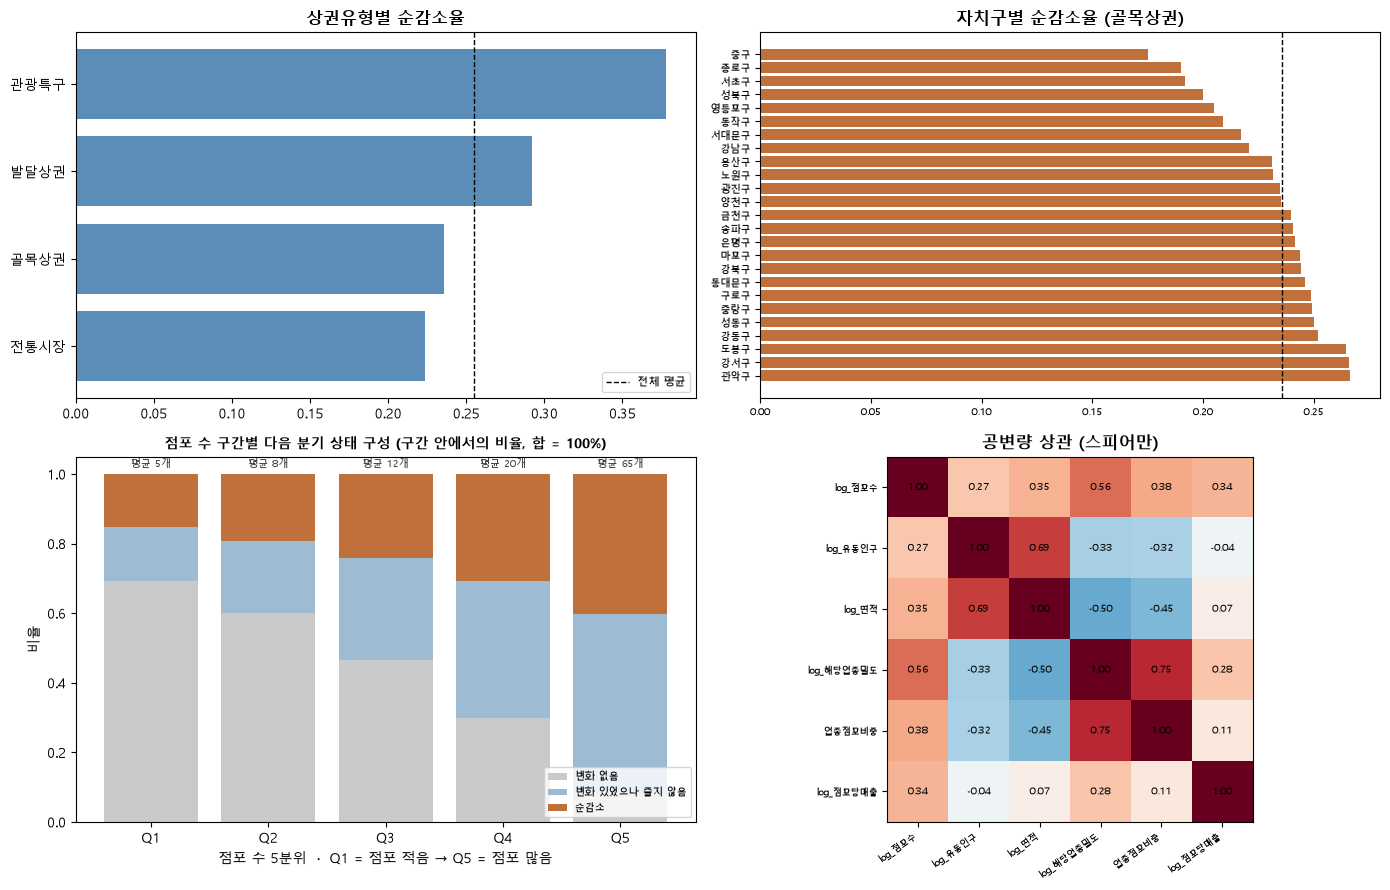

*그림 1*


상관이 큰 쌍 (스피어만)
  log_해당업종밀도       ~ 업종점포비중           +0.753
  log_유동인구         ~ log_면적           +0.692
  log_점포수          ~ log_해당업종밀도       +0.558
  log_면적           ~ log_해당업종밀도       -0.503

|r| > 0.8 인 쌍 0개

※ 0.6이라는 눈금에 규칙은 없음. 그리고 트리 계열 모형에서 상관은 «예측»을 망치지 않음.
  망치는 것은 «해석»임 — SHAP이 상관된 두 변수 사이에 기여를 쪼개 나눠 가져서
  각각의 중요도가 실제보다 낮게 보임. 다음 노트북에서 SHAP 순위를 읽을 때
  위 상위 쌍은 하나의 덩어리로 보아야 함.

## 5. 비교 기준 — 모델이 넘어야 하는 선

모델을 만들기 전에 «아무것도 안 하는 규칙»이 얼마나 맞히는지 먼저 재 둠. 이 값을 넘지 못하면 모델을 쓸 이유가 없음. 네 가지 기준을 세움 — 무작위, 직전 분기, 서울시 상권변화지표, 점포 수임.

«점포 수»를 반드시 넣어야 함. 큰 칸일수록 사건이 자주 일어나고 그만큼 순감소로 잡힐 확률도 높으므로, 점포 수 하나만 알아도 어느 정도는 맞힘. 이 기준을 세워 두지 않으면 모델의 성능이 «위험을 읽어낸 것»인지 «그냥 큰 칸을 고른 것»인지 구분할 수 없음.



,기준선,위험으로 찍은 수,정밀도,재현율,Lift
0,무작위(전부 위험),67475,0.255,1.000,1.000
1,직전 분기,15682,0.284,0.259,1.115
2,상권변화지표(HL),12608,0.244,0.179,0.956
3,"점포 수(상위 15,682칸)",15682,0.394,0.359,1.545


기저율 = 25.5%  <- 모델은 이 표의 Lift를 넘어야 의미가 있음

y,0,1
순감소_현재,,
0,39057,12736
1,11228,4454


chi2(1) = 92.1, p = 8.15e-22, Cramer V = 0.037, 오즈비 = 1.22
-> p는 사실상 0이지만 V가 작으면 직전 분기만으로는 예측력이 약하다는 뜻임. p-value만 보고 결론을 내면 안 되는 이유의 실물임.

## 6. 점포 수를 고정하면 무엇이 남는가

전체 표본에서 잰 값에는 «규모가 큰 칸을 골라낸 몫»이 포함되어 있음. 그래서 점포 수 5분위 안에서 같은 기준을 다시 재 봄. 층 안에서는 칸의 크기가 서로 비슷하므로, 여기서도 값이 1을 넘으면 그 기준은 규모가 아닌 무언가를 읽고 있다고 말할 수 있음.



,칸수,평균점포,기저율,직전 분기 Lift,상권변화지표 Lift,점포 수 Lift
규모구간,,,,,,
Q1,15520,5.4,0.151,0.947,1.014,1.131
Q2,14018,7.9,0.193,0.963,1.054,1.151
Q3,12139,11.7,0.243,1.000,1.009,1.094
Q4,12718,19.6,0.308,0.955,1.056,1.096
Q5,13080,65.5,0.403,1.013,0.969,1.064


-> «점포 수» 의 층내 Lift가 1 근처로 내려가면, 전체 표본에서의 성능이
   상권의 위험을 읽은 것이 아니라 규모를 고른 결과였다는 뜻임.

## 7. 검정 방법의 선택 — 정규성과 등분산성

그룹 간 차이를 무엇으로 검정할지는 분포가 정함. 정규성과 등분산성이 성립하면 ANOVA, 아니면 비모수 검정을 씀. 순서를 거꾸로 하면 안 되므로 먼저 확인함.

라벨이 0/1 이진값이므로 그 자체에 Shapiro-Wilk를 걸면 의미가 없음. 이진 변수는 정의상 정규분포가 아니고 표본만 크면 p는 반드시 0으로 나옴. 그래서 검정 단위를 연속량으로 올림 — 상권 × 업종 칸마다 12분기의 순감소 비율을 계산하면 0~1 사이의 연속값이 되고, 이것이 그룹 간에 비교할 위험 수준의 자연스러운 단위임. 관측이 6분기 미만인 칸은 비율이 불안정하므로 제외함.

Levene 검정은 평균 대신 중앙값 기준으로 함. 분포가 치우쳐 있을 때 평균 기준 Levene은 그 자체로 왜곡됨.

검정만으로 끝내지 않고 Q-Q plot과 Boxplot을 함께 봄. Shapiro-Wilk는 «정규분포가 아니다»만 말하고 어떻게 아닌지는 말하지 않으므로, 꼬리가 긴 것인지 여러 봉우리인지에 따라 대응이 달라짐.



칸 단위 표본 5,687개 (관측 6분기 이상) · 순감소비율 평균 0.249 · 중앙값 0.250
제외된 칸 735개

,그룹 수,정규성 위배,정규성 성립 그룹,Levene stat,Levene p,등분산성
구분,,,,,,
상권유형,4,4/4,없음,16.000,2.35e-10,위배
서비스_업종_코드_명,10,10/10,없음,10.833,7.2e-17,위배
자치구,25,25/25,없음,1.448,0.0727,성립


→ 정규성·등분산성이 성립하지 않으면 주 검정은 Kruskal-Wallis로 감.
  ANOVA는 참고로만 병행함.

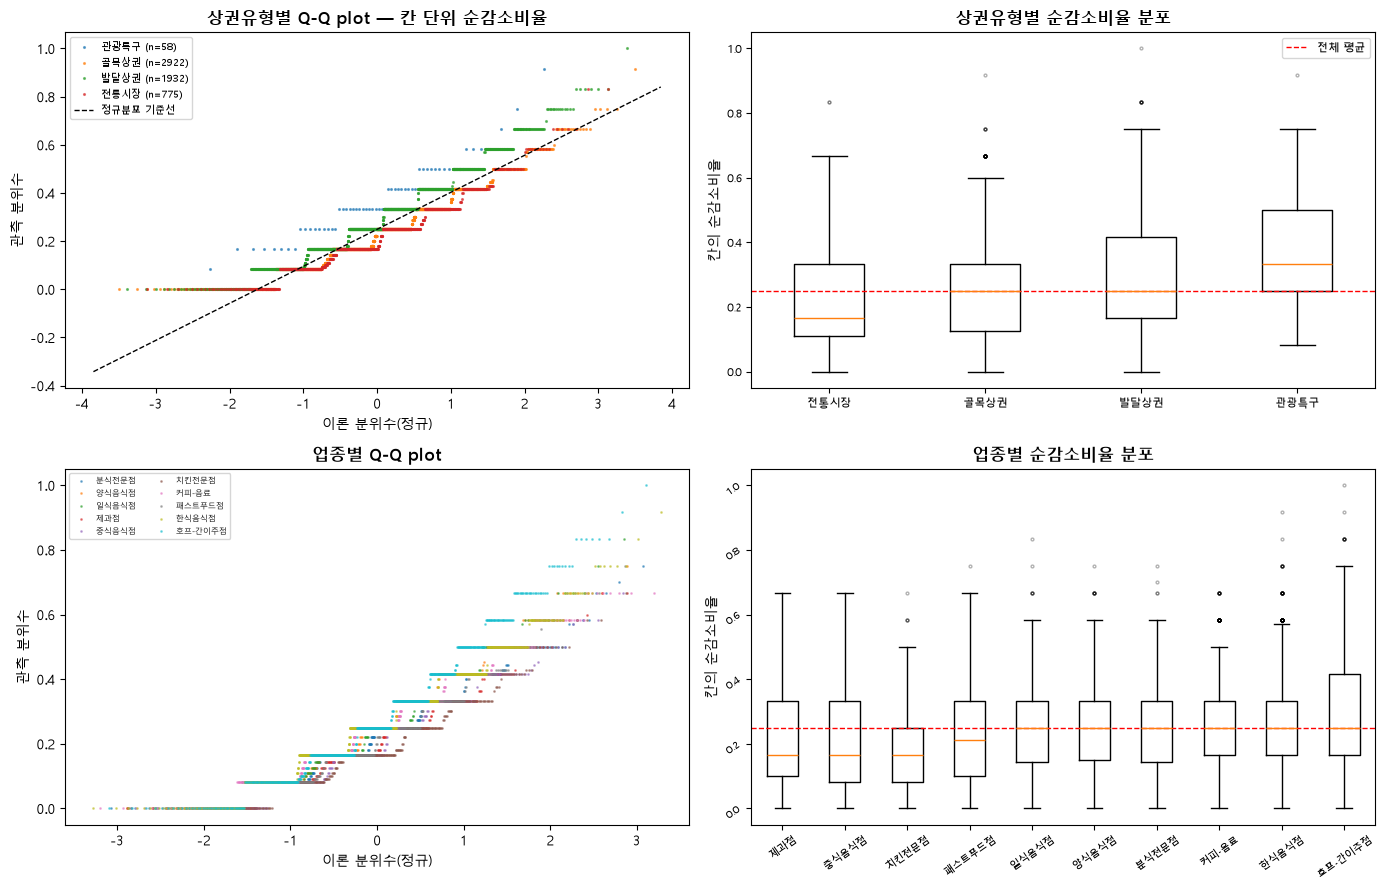

*그림 2*


전체 분포  왜도 +0.592 · 첨도 +0.288 · 순감소가 한 번도 없던 칸 7.1%
→ 왜도가 양수이고 0에 몰린 칸이 많으면 오른쪽 꼬리가 긴 분포임.
  Q-Q plot에서 왼쪽 끝이 바닥에 눌려 있는 계단 모양으로 나타남 —
  «12분기 중 순감소가 0회»인 칸이 한 값에 쌓이기 때문임.
  이 형태에서는 평균 비교(ANOVA)가 중앙값 비교(Kruskal-Wallis)보다 불리함.

## 8. 가설 직접 검증 — 업종 × 상권유형 · 업종 × 자치구

전체를 한 번에 검정하면 업종 구성이 섞여 들어감. 특정 유형에 특정 업종이 몰려 있으면 유형 효과와 업종 효과가 붙어 버림. 그래서 업종을 하나로 고정한 뒤 그 안에서 상권유형 간 차이를 봄. «동일 업종이라도 상권유형에 따라 다른가»를 문자 그대로 검정하는 형태임.

10개 업종에 같은 검정을 반복하므로 Bonferroni 보정을 적용함. 효과크기는 ε²로 내며 0.01 작음 / 0.06 중간 / 0.14 큼을 기준으로 함. 표본이 커서 p는 거의 항상 유의하므로 실제 판정은 효과크기가 함.

자치구 비교는 골목상권만 떼어 수행함. 유형을 고정해 유형 효과를 제거한 상태에서 입지 효과를 보기 위함임. 다만 이 조건에서는 표본이 20칸 이상인 업종이 소수로 줄어 검정력이 낮아지는 한계가 있음.



업종 × 상권유형 — 업종을 고정하고 유형 간 차이를 봄

,그룹수,H,n,p-value,유의,eps2
업종,,,,,,
호프-간이주점,3,86.9,709,1.38e-19,True,0.1202
커피-음료,3,67.4,1006,2.27e-15,True,0.0652
한식음식점,3,81.0,1306,2.54e-18,True,0.0607
양식음식점,3,18.8,352,8.1e-05,True,0.0483
분식전문점,3,32.5,637,8.84e-08,True,0.0481
일식음식점,3,15.6,307,0.000409,True,0.0448
제과점,3,12.9,347,0.00155,True,0.0318
중식음식점,3,11.0,302,0.00413,True,0.0300
패스트푸드점,3,7.1,322,0.0281,False,0.0161


Bonferroni α = 0.0050 · 유의 8/10개 · eps2 0.0002~0.1202

업종 × 자치구 (골목상권만 — 유형을 고정해 유형 효과를 제거함)

,그룹수,H,n,p-value,유의,eps2
업종,,,,,,
한식음식점,24,41.1,815,0.0116,False,0.0229
호프-간이주점,7,9.1,152,0.168,False,0.0214
커피-음료,23,33.4,622,0.057,False,0.0190


Bonferroni α = 0.0050 · 유의 0/3개 · eps2 0.0190~0.0229

평균 eps2   상권유형 0.0465 · 자치구 0.0211
→ 효과크기가 더 큰 쪽은 «상권유형». 위험이 «유형이라는 범주»보다
  «구체적 입지»에 더 좌우되는지를 이 비교가 판정함.

## 9. 성향점수매칭 — 조건을 맞추고 다시 비교

업종 간 단순 비교에서는 공변량이 심각한 불균형 상태임. 그 상태의 격차는 «업종 차이»가 아니라 «규모 차이»를 읽은 것일 수 있음. «불균형이라 비교가 성립하지 않는다»에서 멈추면 질문에 답을 못 한 것이므로, 규모·유동인구·면적·집객시설이 비슷한 칸끼리 짝을 지어 다시 비교함.

처리군은 한식음식점으로 하며, 순감소율을 보기 전에 미리 고정함. 표본이 가장 크고 골목상권을 대표하는 업종이라는 선험적 근거로 정한 것임. 순감소율이 가장 높은 업종을 고른 뒤 그 격차를 검정하면 선택 효과가 섞여 들어감 — 10개 중 최고를 고르는 행위 자체가 위쪽 꼬리를 뽑기 때문에 차이가 없어도 «최고»는 전체 평균보다 높게 나옴.

매칭은 성향점수의 로짓 거리로 1:1 최근접 이웃을 찾되, 분기를 정확히 일치시키고 비복원으로 함. 분기마다 전체 위험 수준이 다르므로 다른 분기의 칸과 짝지으면 시점 효과가 업종 효과로 잘못 읽힘. 같은 대조군 칸을 여러 번 쓰면 그 칸의 우연한 값이 결과를 반복해서 밀어 올림. 캘리퍼를 두어 너무 먼 짝은 배제하고, 짝을 찾지 못한 처리군의 개수를 기록함.

매칭을 했다고 균형이 맞는 것이 아니므로 매칭 전후 SMD를 나란히 놓고 모두 0.1 아래로 내려왔는지 확인함. 내려오지 않으면 그 뒤의 수치는 읽을 값이 아님.



처리군 한식음식점 9,957칸 · 대조군 24,690칸
성향점수 0.0041~0.9995 · 캘리퍼 0.3455 (logit 표준편차의 0.2배)
공통지지영역 0.0107~0.9990 · 그 안의 처리군 100.0% · 대조군 97.7%


매칭 6,836쌍 · 처리군 매칭률 68.7% · 짝을 못 찾아 제외 3,121개

,매칭 전 SMD,매칭 후 SMD,감소폭,판정
공변량,,,,
log_점포수,0.999,0.026,0.973,균형
log_유동인구,-0.447,0.041,0.405,균형
log_면적,-0.473,0.031,0.442,균형
log_집객시설,-0.406,0.006,0.400,균형
logit_ps,1.553,-0.002,1.551,균형


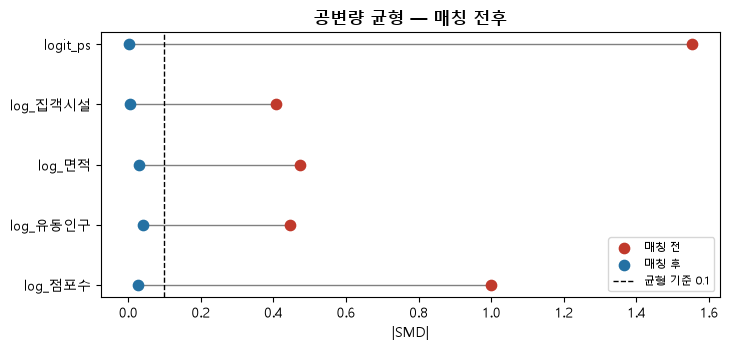

*그림 3*


모든 공변량 |SMD| < 0.1 : 예 — 비교 조건이 맞았으므로 아래 ATT를 읽을 수 있음

매칭 전 단순 격차   0.2527 − 0.2288 = +0.0238  (+2.38%p)
매칭 후 ATT        0.2298 − 0.2844 = -0.0546  (-5.46%p)

McNemar  불일치 쌍 2,613개 (처리군만 순감소 1,120 · 대조군만 순감소 1,493)
         p = 3.11e-13  → 유의
         일치 쌍 4,223개는 검정에 쓰이지 않음


클러스터 부트스트랩 95% CI  [-6.77%p, -3.81%p]  (상권 866개 · 500회)
0을 포함하는가: 아니오 — 방향이 일관됨

→ 단순 격차와 ATT의 **부호가 뒤집혔음.** 단순 비교에서 보였던 격차는 업종 차이가 아니라
  규모·입지 차이(교란)를 읽은 것이었다는 뜻임. 5-4의 «심각한 불균형»이 이 결과의 원인임.

,쌍/칸 수,ATT(%p)
설계,,
매칭 없음(단순 격차),34647,2.38
캘리퍼 0.1×SD,6836,-5.59
캘리퍼 0.2×SD,6836,-5.46
캘리퍼 0.3×SD,6838,-5.47
캘리퍼 0.5×SD,6841,-5.47
복원 허용,9943,-4.43


매칭 설계 5종의 ATT 범위 -5.59 ~ -4.43%p
부호 일치: 예 — 방향은 설계의 산물이 아님
매칭 없음과의 차이: +2.38%p → -5.28%p (매칭 평균)

## 10. 사후검정 — 어느 쌍이 다른가

Kruskal-Wallis는 «어딘가 차이가 있다»까지만 말함. 그룹이 넷이면 가능한 쌍이 여섯인데 그중 어느 쌍이 다른지는 알려주지 않음. Dunn's test는 Kruskal-Wallis와 같은 순위를 그대로 써서 쌍마다 z를 내므로 앞선 검정 결과와 정합적임. 쌍의 개수만큼 Bonferroni 보정함.

동순위 보정을 적용함. 순감소 비율은 0, 1/12, 2/12 같은 값이 반복되어 동순위가 많고, 보정 없이 계산하면 분산이 과대추정되어 유의성이 실제보다 낮게 나옴.

표에는 p-value와 함께 어느 쪽이 높은지를 담음. p만 있으면 방향을 알 수 없기 때문임. 자치구는 쌍이 300개이므로 표 대신 유의성 히트맵과 자치구별 유의 쌍 개수로 정리함.



상권유형 — 순위 중앙값 낮은 순으로 정렬

,median,mean,size
상권유형,,,
전통시장,0.1667,0.2176,775
골목상권,0.2500,0.2282,2922
발달상권,0.2500,0.2894,1932
관광특구,0.3333,0.3779,58


,전통시장,골목상권,발달상권,관광특구
전통시장,1.000,0.321,0.0000,0.0000
골목상권,0.321,1.000,0.0000,0.0000
발달상권,0.000,0.000,1.0000,0.0003
관광특구,0.000,0.000,0.0003,1.0000


,z,p(보정),유의,더 높은 쪽
쌍,,,,
전통시장 ↔ 발달상권,10.41,0.0000,True,발달상권
전통시장 ↔ 관광특구,7.23,0.0000,True,관광특구
골목상권 ↔ 발달상권,12.44,0.0000,True,발달상권
골목상권 ↔ 관광특구,6.84,0.0000,True,관광특구
발달상권 ↔ 관광특구,4.07,0.0003,True,관광특구
전통시장 ↔ 골목상권,1.93,0.3210,False,골목상권


유의한 쌍 5/6개 (Bonferroni 보정 후 α=0.05)

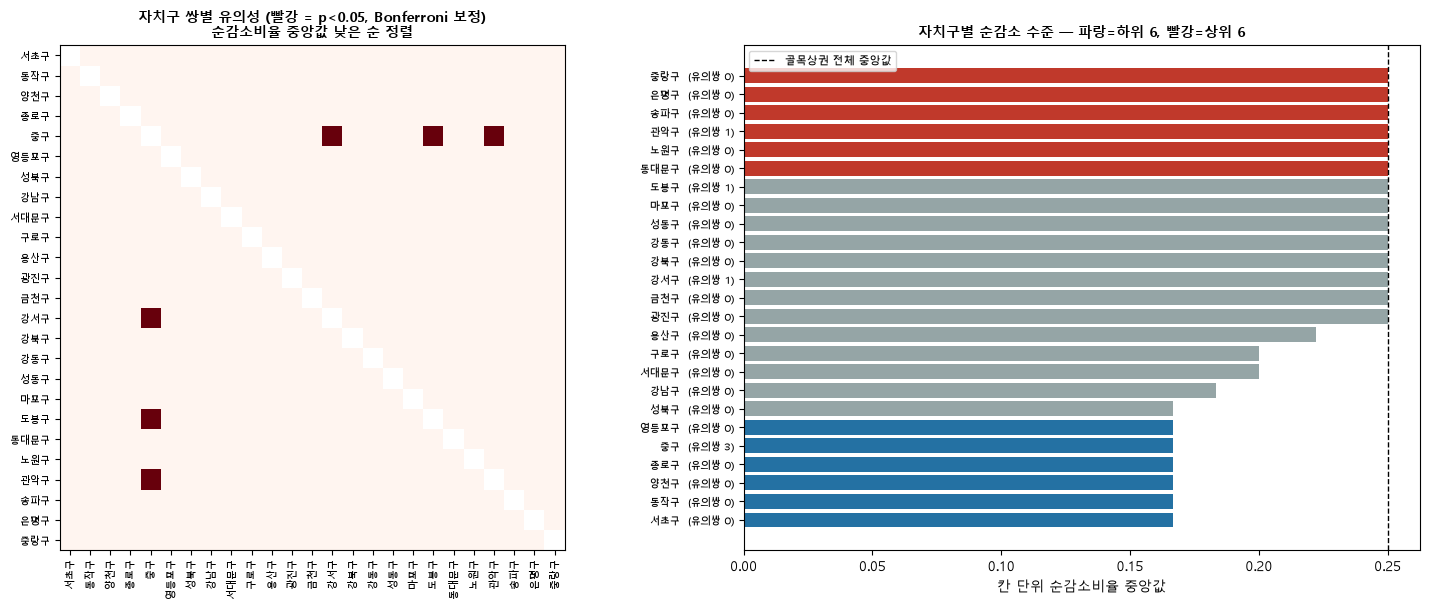

*그림 4*


자치구 25개 · 가능한 쌍 300개 · 유의한 쌍 3개 (1.0%)

가장 낮은 6개 : 서초구, 동작구, 양천구, 종로구, 중구, 영등포구
가장 높은 6개 : 동대문구, 노원구, 관악구, 송파구, 은평구, 중랑구

유의한 쌍이 가장 많은 자치구 (다른 구와 뚜렷이 구분되는 곳)

,유의한 쌍 수
중구,3
도봉구,1
관악구,1
강서구,1
서초구,0
영등포구,0


유의한 쌍이 적은 자치구들은 서로 구분되지 않는 «중간군»을 이룸 —
자치구를 범주로 넣어도 그 안에서는 정보가 적다는 뜻임.

## 11. 계절성

모델 피처에서 연도-분기 코드는 제외함. 학습에 없던 분기에는 값이 없고, 한 분기 안에서 모든 칸이 같은 값이라 그 분기 안의 순위를 바꾸지 못하기 때문임. 반면 분기 순번은 2026년에도 같게 정의되므로 미래 예측에 쓸 수 있음.

다만 분기 순번도 한 분기 안에서는 상수이므로 테스트 분기 안의 순위는 바꾸지 못함. 여기서 보는 것은 분기 사이의 차이이고, 효과크기를 업종·입지 효과와 비교해 주효과인지 보조요인인지 판정함.



,칸수,순감소율,기저율대비
1분기,16946,0.2481,0.974
2분기,16911,0.2656,1.043
3분기,16823,0.2458,0.965
4분기,16795,0.2595,1.019


Kruskal-Wallis  H = 23.641, p = 2.97e-05, eps2 = 0.0003
최고 2분기 0.2656 · 최저 3분기 0.2458 · 격차 0.0198

비교 — 5-6의 평균 eps2  상권유형 0.0465 · 자치구 0.0211
       계절성 eps2 0.0003
→ 계절성 효과크기가 업종·입지 효과보다 작음. 보조 요인으로 판정함.

## 12. 후보 변수 판별력 점검

새로 넣은 변수가 피처로 쓸 값을 하는지 미리 재 둠. 통과해야 하는 조건이 둘임.

첫째, 분기 안에서 변해야 함. 평가가 한 분기 안의 순위이므로 분기 안에서 상수인 변수는 무엇을 곱하거나 더해도 순위를 바꾸지 못함. 상수 c 에 대해 c × 값 은 값 의 단조 변환이라 줄 세운 결과가 같기 때문임.

둘째, 규모와 다른 축이어야 함. 이미 점포 수가 가장 센 신호이므로 규모와 상관이 높으면 새 정보가 아니라 규모를 우회적으로 다시 넣는 것임.



,분기내 고유값,분기내 변동,AUC,|AUC-0.5|,규모상관
변수,,,,,
운영_영업_개월_평균,126~133,있음,0.473,0.027,-0.092
운영개월_서울대비,126~133,있음,0.468,0.032,-0.099
외식물가지수,1~1,없음(상수),0.514,0.014,0.003
외식지출전망,1~1,없음(상수),0.499,0.001,-0.003
log_점포수,188~198,있음,0.637,0.137,1.000
log_유동인구,1355~1378,있음,0.556,0.056,0.273


판정
  운영_영업_개월_평균          통과 — 약하지만 방향이 있고(AUC 0.473) 규모와 다른 축(상관 -0.09)
  운영개월_서울대비            통과 — 약하지만 방향이 있고(AUC 0.468) 규모와 다른 축(상관 -0.10)
  외식물가지수               탈락 — 분기 안에서 상수라 순위에 기여할 수 없음
  외식지출전망               탈락 — 분기 안에서 상수라 순위에 기여할 수 없음

[운영_영업_개월_평균]

,칸수,평균값,평균점포,순감소율
Q1,14170,82.521004,26.469000,0.278
Q2,14210,97.224998,22.683001,0.266
Q3,13374,105.419998,19.642000,0.252
Q4,12967,114.449997,17.763000,0.247
Q5,12754,136.587006,19.726000,0.228


  단조 예 · 격차 0.050 · 구간 간 평균점포 17.8~26.5
  → 평균점포가 구간에 따라 크게 변하지 않으면 규모 교란이 아니라는 뜻임

경제지표는 분기 안에서 상수이므로 5분위를 나누면 «분기를 나눈 것»과 같아져 의미가 없음.
아래에서 그것을 직접 확인함.

2025Q4 5,479칸에서 각 변수가 갖는 서로 다른 값의 개수
  외식물가지수                    1개
  외식지출전망                    1개
  운영_영업_개월_평균             132개
  전체_점포_수                 188개

외식물가지수·외식지출전망은 5,479칸 전부가 같은 값 하나임.
이 열로는 어떤 칸이 더 위험한지 구분할 수 없음 — 정렬해도 순서가 바뀌지 않기 때문임.
상권 단위 변수와 곱해도 마찬가지임: 상수를 곱하는 것은 단조 변환이라 순위가 보존됨.

분기를 가로지르면 «물가가 높은 분기에는 개업이 적은 것이 더 위험하다» 같은
교호작용이 있을 수 있고, 그것은 트리 모형이 두 변수를 모두 가지면 스스로 잡음.
다만 분기가 12개뿐이고 테스트가 1개 분기이므로, 테스트 분기 안의 순위는 여전히 바뀌지 않음.

## 13. 모델 선정

성격이 다른 다섯 계열을 같은 검증 분기에서 비교함 — 단일 트리, 배깅 앙상블, 선형 확률모형, 마진 기반 분류기, 부스팅임. 불균형은 모든 모델에 가중치로 다뤄 조건을 같게 맞춤.

분할 이전에 오버샘플링을 하지 않음. 복제된 소수 클래스가 학습과 검증에 함께 들어가 성능이 부풀려지기 때문임. 가중치는 그 위험이 없음.

주지표는 AP(Average Precision)이며 정밀도-재현율 곡선 아래 면적임. 양성률이 26% 정도인 소수 사건이라 정확도는 판단 근거가 되지 못함 — 전부 0으로 찍기만 해도 74.7%가 나옴.

채택 모델은 XGBoost임. AP 1위가 아니지만 다섯 모델의 차이가 0.02 미만이어서 모델 선택이 결론을 바꾸지 않고, 트리 구조를 따라 기여를 정확히 분해하는 도구가 있는 유일한 축이기 때문임. 후반부 질문이 «무엇이 위험을 만드는가»이므로 분해 도구가 필요함.



양성 가중치 scale_pos_weight = 2.930

  [완료] 의사결정나무

  [완료] 랜덤포레스트

  [완료] 로지스틱 회귀

  [완료] 선형 SVM

  [완료] XGBoost

,AP,ROC-AUC,F1,정밀도,재현율,정확도,Lift
모델,,,,,,,
랜덤포레스트,0.408,0.676,0.401,0.401,0.401,0.697,1.584
선형 SVM,0.406,0.675,0.418,0.418,0.418,0.705,1.652
로지스틱 회귀,0.406,0.675,0.417,0.417,0.417,0.705,1.646
의사결정나무,0.398,0.667,0.420,0.401,0.441,0.692,1.585
XGBoost,0.398,0.665,0.405,0.405,0.405,0.699,1.601


검증 AP 1위 = 랜덤포레스트 (0.408)
채택 모델      = XGBoost (0.398)
→ XGBoost는 이 표에서 1위가 아님 (차이 +0.010). 7장 최종 평가에서 랜덤포레스트와 나란히 보고함.
참고: 전부 0으로 찍어도 정확도는 74.7% 임 — 정확도로 고르면 안 되는 이유

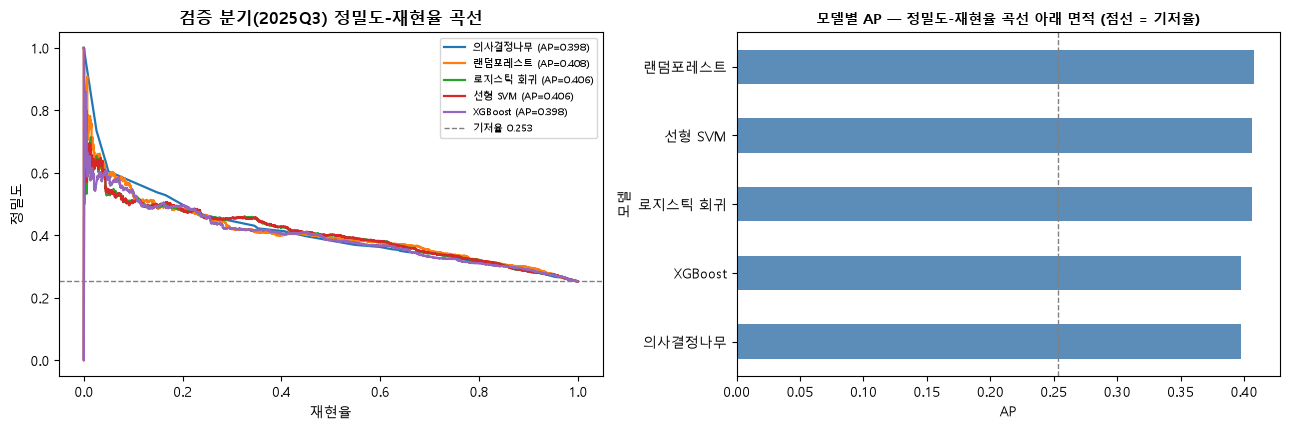

*그림 5*


## 14. 작동점 — 몇 칸을 위험으로 찍을 것인가

기저율과 같은 비율을 위험으로 찍는 설정은 조기경보의 실제 운영과 맞지 않음. 전체의 20%가 넘는 칸에 경보를 울리는 운영은 없고, 손이 닿는 수십~수백 곳을 찍음.

작동점은 검증 분기에서 고름. 테스트 결과를 본 뒤 «잘 나오는 지점»을 고르면 그 순간 테스트가 검증이 되어 버림. 검증에서 정한 값을 테스트에 그대로 옮겨 쓰고, 테스트 표의 다른 작동점은 참고로만 함께 보임.



,검증 정밀도,검증 ÷ 기저율
위험으로 찍은 수,,
50,0.580,2.292
100,0.600,2.371
200,0.555,2.193
300,0.513,2.028
500,0.488,1.928
800,0.448,1.768
1285,0.412,1.627
2000,0.378,1.494


검증 분기에서 정밀도가 가장 높은 작동점 = 상위 100칸
이 값을 테스트에 그대로 옮겨 씀

,XGBoost 정밀도,점포 수 정밀도,XGBoost ÷ 기저율,점포 수 ÷ 기저율,두 목록 겹침,XGBoost 평균점포
위험으로 찍은 수,,,,,,
50,0.720,0.380,2.772,1.463,0.100,108.620
100,0.600,0.460,2.310,1.771,0.230,100.980
200,0.575,0.520,2.214,2.002,0.360,82.425
300,0.533,0.493,2.054,1.899,0.413,74.143
500,0.494,0.464,1.902,1.787,0.516,65.012
800,0.441,0.459,1.699,1.766,0.619,57.014
1285,0.398,0.427,1.531,1.645,0.687,47.151
2000,0.376,0.383,1.448,1.475,0.742,38.217


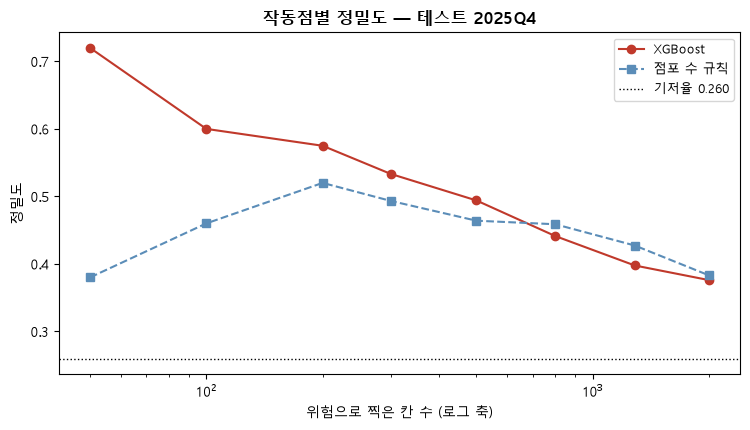

*그림 6*


검증에서 고른 작동점 — 상위 100칸에서의 테스트 성능
  모델 정밀도     0.600  (기저율의 2.31배)
  점포 수 정밀도   0.460  (기저율의 1.77배)
  두 목록 겹침     23%

모델 정밀도가 더 높은 작동점: [50, 100, 200, 300, 500]
  상위 50칸  모델 0.720 · 점포 수 0.380 (기저율의 2.77배)
  두 목록 겹침 10% — 서로 다른 상권을 지목함

→ 상위 소수를 찍는 작동점에서는 모델 정밀도가 더 높고,
  많이 찍을수록 «점포 수» 규칙과 값이 가까워짐.
  많이 찍으면 결국 큰 상권을 다 담게 되어 두 방법이 같아지기 때문임.
  즉 «전체 값이 낮다»는 것은 한 작동점의 성질이지 모델 전체의 성질이 아님.

,자치구,상권_코드_명,상권유형,서비스_업종_코드_명,전체_점포_수,개업_점포_수,폐업_점포_수,위험점수,y
1,강서구,발산역(마곡),발달상권,호프-간이주점,108.0,1.0,6.0,0.951,1
2,마포구,연남동(홍대),발달상권,호프-간이주점,149.0,4.0,14.0,0.947,1
3,광진구,건대입구역(건대),발달상권,호프-간이주점,145.0,6.0,4.0,0.939,0
4,강서구,강서구청,발달상권,호프-간이주점,84.0,3.0,3.0,0.935,1
5,강남구,압구정로데오역(압구정로데오),발달상권,호프-간이주점,88.0,3.0,13.0,0.922,1
6,강서구,발산역(마곡),발달상권,커피-음료,143.0,7.0,9.0,0.918,0
7,마포구,연남동(홍대),발달상권,커피-음료,215.0,6.0,6.0,0.914,1
8,강북구,수유역,발달상권,호프-간이주점,135.0,1.0,9.0,0.914,1
9,마포구,홍대입구역(홍대),발달상권,호프-간이주점,270.0,7.0,21.0,0.905,1
10,용산구,이태원(이태원역),발달상권,호프-간이주점,142.0,5.0,13.0,0.901,1


골목상권 2,772칸 중 위험 판정 496칸 (17.9%) · 실제 순감소율 23.1%
위험 판정 칸의 실제 순감소율 32.9% vs 미판정 21.0%

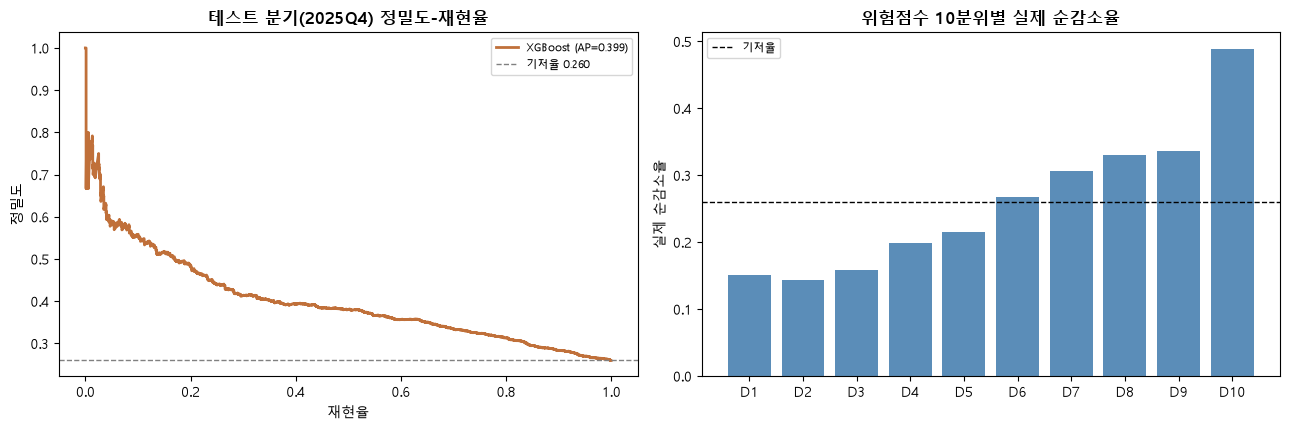

*그림 7*


→ 오른쪽이 단조 증가하면 점수가 위험 순서를 제대로 매기고 있다는 뜻임

## 15. 테스트 분기 최종 평가

학습 2023Q1~2025Q2, 검증 2025Q3, 테스트 2025Q4로 시간 순서대로 나누고 섞지 않음. 각 분기는 그 다음 분기의 결과로 채점함.

검증과 테스트는 역할이 다름. 검증은 모델을 고르고 임계값을 정하는 데 쓰므로 그 점수는 낙관적으로 치우침. 테스트는 결정이 끝난 뒤 한 번만 보므로 치우치지 않음. 임계값은 검증 분기에서 정한 것을 그대로 옮겨 씀.

2025년 4분기는 미래가 아니라 이미 지난 분기이므로 엄밀히는 홀드아웃임. 학습과 모델 선택에 일절 쓰지 않았다는 의미에서 테스트라고 부름.



,테스트 2025Q4
AP,0.399
ROC-AUC,0.648
정밀도,0.395
재현율,0.372
F1,0.384
정확도,0.689
Lift,1.522


      예측 0  예측 1
실제 0  3245   811
실제 1   893   530

기저율 26.0% · 위험으로 찍은 칸 1,341개

기준선 대비
  무작위(전부 위험)             Lift 1.000
  직전 분기                  Lift 1.199
  상권변화지표(HL)             Lift 0.937
  점포 수(상위 1,285칸)        Lift 1.645
  XGBoost                Lift 1.522

## 16. 두 단계로 나눈 모형

라벨은 두 개의 다른 일이 겹친 사건임. 하나는 다음 분기에 개·폐업이 한 건이라도 일어나는가이고, 다른 하나는 일어났다면 그것이 줄어드는 쪽인가임. 이를 두 모형으로 나누어 각각 추정하고 곱함.

곱하는 것은 근사가 아니라 정확한 등식임. 순감소는 반드시 사건의 부분집합이므로 — 폐업이 개업보다 많으면 폐업이 최소 한 건 있음 — 사건이 없는 경우의 순감소 확률이 정확히 0으로 사라짐.

나누는 실익은 규모 편향의 분리임. 앞에서 본 «작은 상권은 위험해서가 아니라 작아서 아무 일도 일어나지 않는다»는 문제가 1단계에 갇힘. 2단계는 이미 일이 일어난 칸만 보므로 그 편향이 원리적으로 들어올 수 없음.



분해가 정확한 등식인지
  P(사건)                0.5608
  P(순감소 | 사건)         0.4543
  곱                     0.2548
  P(순감소) 실제           0.2548   ← 곱과 같아야 함
  P(순감소 | 사건 없음)     0.0000  (해당 칸 중 y=1 이 0건)

두 단계가 규모와 맺는 관계 (스피어만)
  사건 여부    ~ log_점포수  +0.448
  순감소 | 사건 ~ log_점포수  -0.039

→ 규모 의존이 1단계에 거의 전부 몰려 있고, 2단계는 규모와 거의 무관함.
  이것이 «나누면 좋은 이유»의 실물임 — 2단계가 규모 편향 없는 위험 판단이 됨.

,AP,ROC-AUC,정밀도,재현율,Lift
방법,,,,,
단일 모형 (XGBoost),0.398,0.665,0.405,0.405,1.601
2단계 모형,0.405,0.673,0.421,0.421,1.663


1단계 P(사건) 검증 AP 0.810  (사건 발생률 52.2%)

검증 AP가 더 높은 쪽 = 2단계 모형 (차이 +0.007)

이후 장(해석·지도)은 «단일 모형»으로 진행함. 이유는 성능이 아니라 분해 가능성임 —
2단계 모형의 최종 점수는 두 모형의 «곱»이라 SHAP처럼 기여를 더해 분해할 수 없음.
따라서 2단계 모형은 «단일 모형이 규모 편향에 끌려간 것이 아닌지» 확인하는
강건성 점검으로 보고하고, 7장에서 테스트 성능을 나란히 제시함.

## 17. 두 확률로 나눈 상권 유형

두 확률은 서로 다른 것을 재기 때문에, 곱해서 하나로 합치지 않고 두 축으로 두면 상권의 성격이 갈림. 사건 확률이 «얼마나 활발하게 변하는가»를, 순감소 조건부 확률이 «변할 때 어느 방향인가»를 나타냄.

네 유형은 다음과 같음. 사건 확률과 조건부 확률이 모두 높으면 «활발하게 변하면서 쇠퇴하는 상권», 사건 확률은 높고 조건부 확률이 낮으면 «활발하게 변하지만 성장·유지되는 상권», 사건 확률은 낮고 조건부 확률이 높으면 «정체되어 있지만 변화가 생기면 취약한 상권», 둘 다 낮으면 «안정적인 상권»임.

이 구분이 필요한 이유는, 최종 위험도(두 확률의 곱)로 줄 세우면 사건 확률이 높은 쪽 — 즉 점포가 많은 상권이 앞으로 오고 작은 상권은 뒤로 밀리기 때문임. 그런데 뒤로 밀리는 쪽에 «조용하지만 한 번 흔들리면 버티지 못하는» 유형이 들어 있음. 순위 하나로 합치면 그 구분이 사라짐.

경계는 검증 분기의 중앙값으로 정함. 테스트 분기의 분포를 보고 자르면 그 순간 테스트가 검증이 됨. 두 축의 이름이 데이터와 맞는지는 다음 분기 실측으로 검산함 — 사건 축은 사건의 실제 발생률로, 방향 축은 사건이 난 칸만 골라 본 순감소 비율로 확인함. 분모를 «사건이 난 칸»으로 제한해야 조건부 확률의 검산이 됨.



검증 분기 중앙값으로 정한 경계  사건확률 0.4259 · 순감소조건부확률 0.5045

표 71

테스트 분기 기저율 0.260

,사건_수준,방향_수준,유형,칸수,사건_실제발생률,사건있던칸,순감소_조건부실제,전체_순감소율
0,낮음,낮음,안정적,1229,0.343,422,0.483,0.166
1,낮음,높음,정체되어 있으나 변화 시 취약,1535,0.333,511,0.577,0.192
2,높음,낮음,활발하게 변하나 성장·유지,1529,0.733,1120,0.436,0.319
3,높음,높음,활발하게 변하면서 쇠퇴,1186,0.677,803,0.543,0.368


검산
  사건 실제발생률      사건확률 높음 0.705 vs 낮음 0.338  → 이름과 일치
  순감소 조건부 실제    방향 높음 0.560 vs 낮음 0.460  → 이름과 일치

참고 — 현재 분기 개업·폐업 (라벨과 시점이 다르므로 검산에는 쓰지 않음)

,유형,평균개업,평균폐업,개폐업합,개업-폐업
0,안정적,0.14,0.35,0.48,-0.21
1,정체되어 있으나 변화 시 취약,0.26,0.16,0.43,0.10
2,활발하게 변하나 성장·유지,1.11,1.44,2.55,-0.33
3,활발하게 변하면서 쇠퇴,1.22,1.11,2.33,0.12


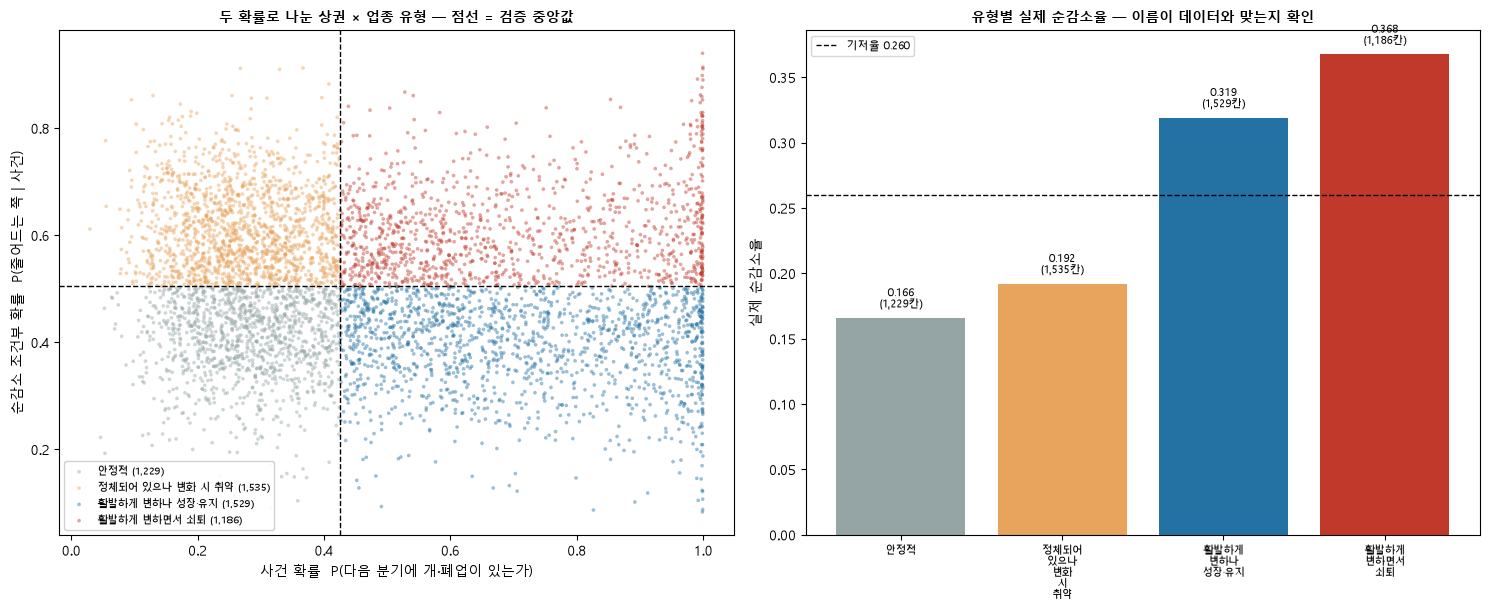

*그림 8*


가운데 두 유형 — 최종 위험도로 줄 세우면 어떻게 되는가

,유형,칸수,평균최종위험도,실제순감소율,평균점포
1,정체되어 있으나 변화 시 취약,1535,0.166,0.192,7.550
2,활발하게 변하나 성장·유지,1529,0.277,0.319,35.572


최종 위험도로 줄 세우면  «활발하게 변하나 성장·유지» 0.277  >  «정체되어 있으나 변화 시 취약» 0.166
평균 점포 수는           35.6개  vs  7.5개  (4.7배)

→ 곱 하나로 줄 세우면 «점포가 많은 쪽»이 앞에 오고, 작은 상권은 뒤로 밀림.
  그런데 뒤로 밀린 쪽이 «조용하지만 한 번 흔들리면 버티지 못하는» 유형임.
  칸 수가 비슷한데 성격이 정반대이므로, 하나의 순위로 합치면 이 구분이 사라짐.
  두 확률을 두 축으로 남겨 두어야 «어느 쪽에 어떤 대응이 필요한가»를 말할 수 있음.

표 79

골목상권만 떼어 유형 구성을 봄

,칸수,비중,실제순감소율
유형,,,
안정적,687,0.248,0.170
정체되어 있으나 변화 시 취약,963,0.347,0.188
활발하게 변하나 성장·유지,659,0.238,0.294
활발하게 변하면서 쇠퇴,463,0.167,0.322


골목상권 2,772칸 · 전체 순감소율 0.231

## 18. 무엇이 위험을 만드는가

모형이 자체로 내놓는 변수 중요도는 변수 사이의 의존성을 무시함. SHAP은 각 변수가 예측을 어느 방향으로 얼마나 밀었는지를 개별 예측 단위로 분해하므로 «무엇이 위험을 만드는가»에 답하기에 적합함.

규모·밀도 계열이 차지하는 기여 비중을 따로 계산함. 앞에서 본 «라벨이 규모에 끌려간다»는 우려가 모형에 얼마나 남아 있는지를 수치로 남기기 위함임.

2단계 모형은 단계별로 따로 SHAP을 내면 답이 갈라짐. 1단계는 무엇이 사건을 일으키는가를, 2단계는 사건이 났을 때 무엇이 줄어드는 쪽으로 미는가를 보여 줌. 2단계 상위에 오는 변수가 «크기와 무관하게 위험을 만드는 것»임. 곱을 한 장으로 합치는 것은 되지 않음 — SHAP은 기여를 더해서 설명하는데 최종 점수가 두 확률의 곱이기 때문임. 로그를 취하면 가법이 되므로 합산 기여도는 보조로 냄.



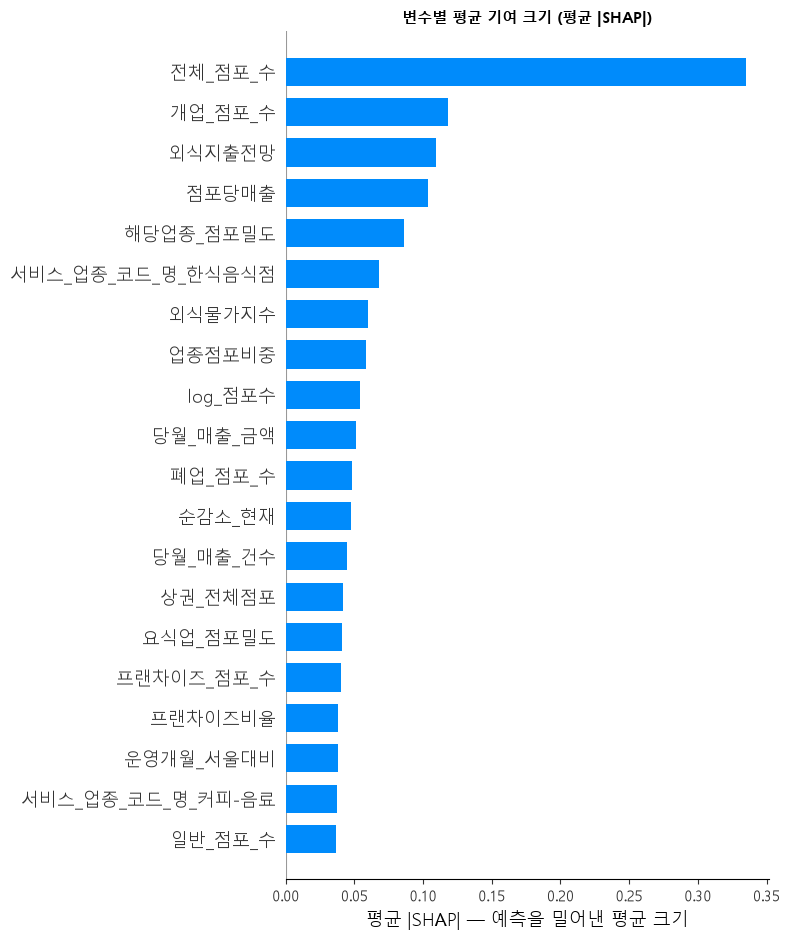

*그림 9*


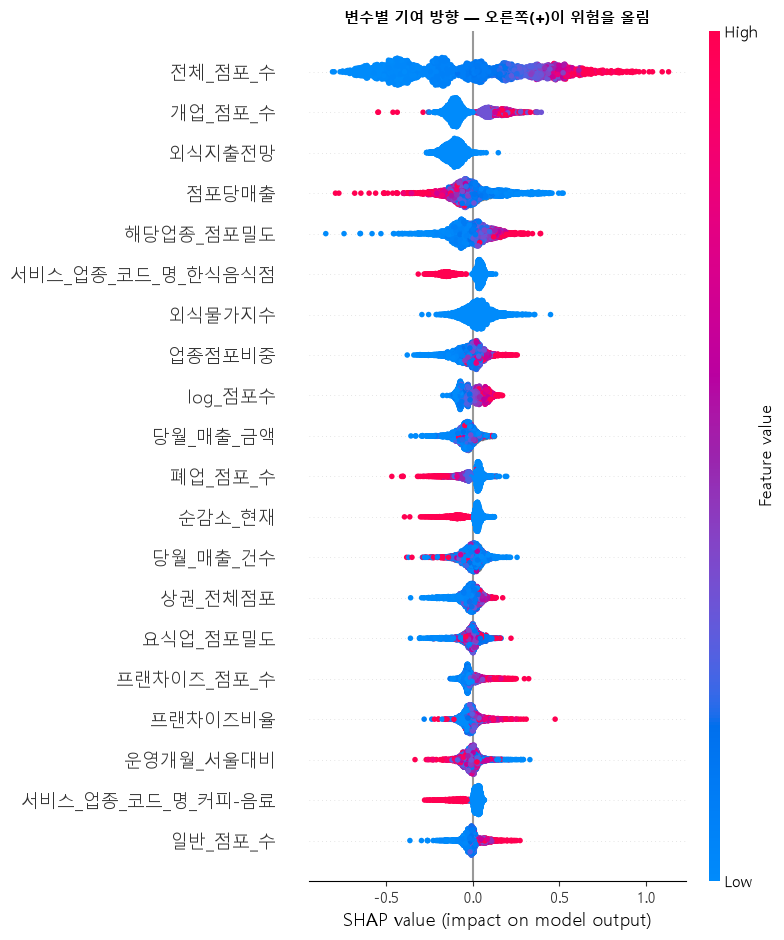

*그림 10*


,평균 |SHAP|
전체_점포_수,0.3350
개업_점포_수,0.1181
외식지출전망,0.1096
점포당매출,0.1033
해당업종_점포밀도,0.0863
서비스_업종_코드_명_한식음식점,0.0679
외식물가지수,0.0600
업종점포비중,0.0583
log_점포수,0.0543
당월_매출_금액,0.0515


규모·밀도 계열이 차지하는 기여 비중 53.1%
그 밖의 변수 46.9%

규모 계열 상위

,평균 |SHAP|
전체_점포_수,0.3350
개업_점포_수,0.1181
해당업종_점포밀도,0.0863
log_점포수,0.0543
폐업_점포_수,0.0483
상권_전체점포,0.0418
요식업_점포밀도,0.0406
프랜차이즈_점포_수,0.0405


규모 밖 상위

,평균 |SHAP|
외식지출전망,0.1096
점포당매출,0.1033
서비스_업종_코드_명_한식음식점,0.0679
외식물가지수,0.0600
업종점포비중,0.0583
당월_매출_금액,0.0515
순감소_현재,0.0474
당월_매출_건수,0.0443
프랜차이즈비율,0.0381
운영개월_서울대비,0.0378


규모·밀도 계열이 차지하는 기여 비중
  단일 모형          53.1%
  1단계 P(사건)       65.4%
  2단계 P(순감소|사건)  38.3%   ← 규모를 조건으로 걸었을 때 남는 몫

,1단계 |SHAP|,2단계 |SHAP|,1단계 순위,2단계 순위
log_면적,0.0092,0.0091,42,47
log_요식업밀도,0.0140,0.0196,38,32
log_유동인구,0.0190,0.0138,33,38
log_점포당매출,0.0183,0.0253,34,28
log_점포수,0.1302,0.0131,2,39
log_해당업종밀도,0.0092,0.0117,43,42
개업_점포_수,0.0633,0.1031,7,3
관공서_수,0.0047,0.0072,58,49
극장_수,0.0051,0.0032,57,63
당월_매출_건수,0.0514,0.0561,11,11


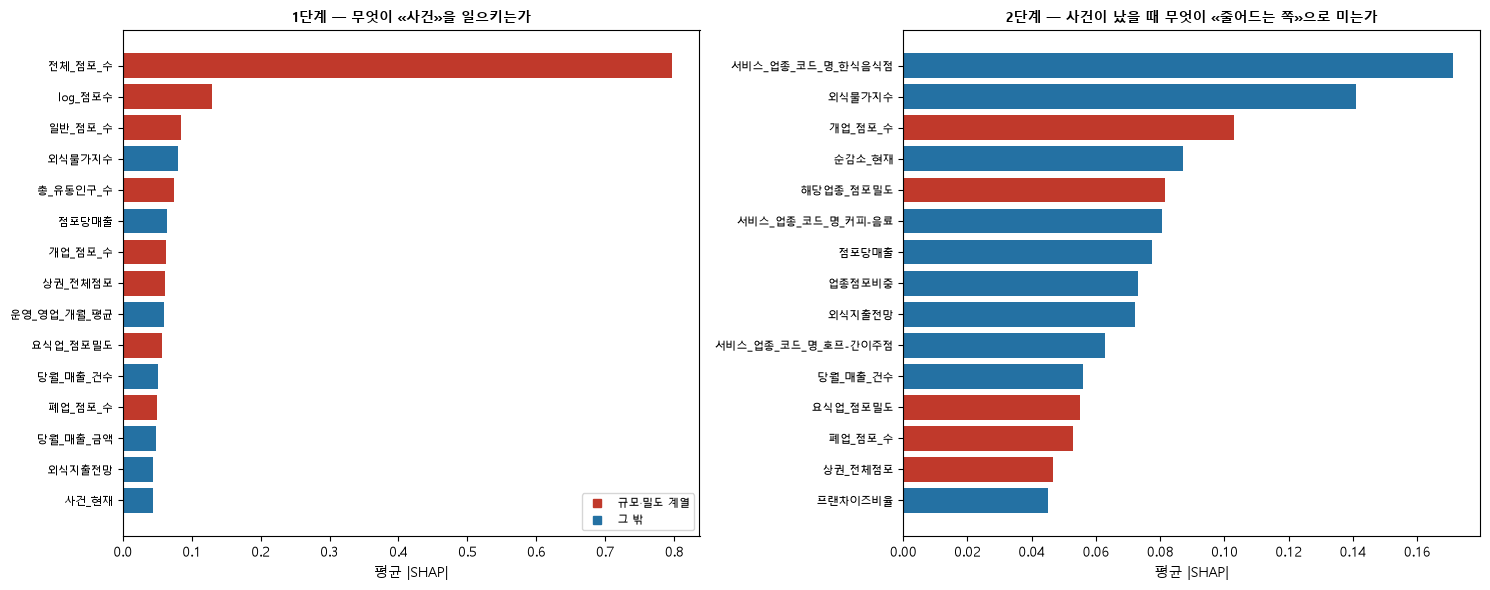

*그림 11*


2단계 상위 — 규모 계열을 뺀 목록 (규모를 조건으로 걸었을 때의 위험 요인)

,2단계 평균 |SHAP|
서비스_업종_코드_명_한식음식점,0.1710
외식물가지수,0.1408
순감소_현재,0.0869
서비스_업종_코드_명_커피-음료,0.0807
점포당매출,0.0775
업종점포비중,0.0730
외식지출전망,0.0720
서비스_업종_코드_명_호프-간이주점,0.0628
당월_매출_건수,0.0561
프랜차이즈비율,0.0450



보조 — 두 단계 기여를 더한 순위 (로그확률 기준, 상위 10)

,합산 |SHAP|
전체_점포_수,0.8361
외식물가지수,0.2215
서비스_업종_코드_명_한식음식점,0.2110
개업_점포_수,0.1664
log_점포수,0.1433
점포당매출,0.1419
총_유동인구_수,0.1184
해당업종_점포밀도,0.1171
외식지출전망,0.1163
요식업_점포밀도,0.1119


합산은 «두 단계 중 어디서든 많이 쓰인 변수»를 보여 줌.
규모 변수는 1단계에서, 그 밖의 변수는 2단계에서 올라오는 구조가 그대로 나타남.

## 19. 위험도 공간 분석

원본 좌표의 단위는 미터이고 좌표계는 EPSG:5181임. 지도 라이브러리가 알아듣는 것은 위경도이므로 변환이 필요하되, 두 벌을 유지함 — 그릴 때는 위경도, 거리를 잴 때는 원본 미터 좌표임. 위경도는 1도의 실제 길이가 위도마다 달라 뺄셈으로 거리를 구할 수 없음.

좌표계 검증은 실제로 어디인지 아는 상권으로 함. 후보 좌표계들이 서울 안에서 2km 이내로 붙어 있어 경계 상자만으로는 어느 것이 맞는지 갈라지지 않기 때문임. 지하철역 상권의 실제 위경도와 대조해 좌표계를 확정하고, 서울 경계 상자를 벗어나는 좌표가 없는지 함께 확인함.

위험등급은 보기 좋은 눈금이 아니라 위험점수의 4분위로 자름. 각 등급의 실제 순감소율을 붙여 그 등급이 정말 위험을 구분하는지 확인하고, 눈금으로 자르는 방식과 같은 데이터로 나란히 비교함.

상권 경계 폴리곤을 확보하지 못해 단계구분도는 그리지 못함. 좌표만으로 그릴 수 있는 버블 분포도·격자 분석·동심원 분석·공간 평활 네 레이어로 같은 질문에 답함.



,평균오차_km,최대오차_km
좌표계,,
EPSG:5181,0.284,0.489
EPSG:5174,0.561,0.799
EPSG:2097,0.559,0.799


검증 ① 기준점 6곳 대조 → 채택 좌표계 = EPSG:5181

,상권명,변환 경도,변환 위도,실제 경도,실제 위도,오차_km
기준점,,,,,,
홍대입구역,홍대입구역 3번,126.9256,37.5599,126.9237,37.5568,0.387
강남역,강남역,127.0278,37.4976,127.0276,37.4979,0.039
잠실역,잠실역,127.1013,37.5140,127.1000,37.5133,0.136
여의도역,여의도역(여의도),126.9263,37.5227,126.9244,37.5215,0.211
사당역,사당역 10번,126.9782,37.4794,126.9816,37.4765,0.445
노원역,노원역 9번,127.0632,37.6592,127.0611,37.6551,0.489


→ 강남역처럼 상권명이 역 이름 그대로인 곳은 오차 0.05km 안쪽. 좌표계가 맞음

검증 ② 서울 경계 상자 밖  0건 / 5,479건 (0.000%)
          경도 126.8020 ~ 127.1738 · 위도 37.4346 ~ 37.6898
          결측 좌표 0건

지도에 쓸 표본 5,479칸 (경계 상자 통과분만)

,칸수,평균위험점수,실제순감소율,평균점포,기저율대비
위험등급,,,,,
관찰,1370,0.209,0.153,8.547,0.59
주의,1370,0.345,0.194,12.060,0.75
경계,1369,0.461,0.299,19.187,1.15
위험,1370,0.643,0.393,45.672,1.51


«관찰» 15.3%  →  «위험» 39.3%   (2.6배)
→ 등급이 올라갈 때 실제 순감소율도 단조 증가하면 이 분류는 쓸 수 있음

눈금 기준 (현재 분기 순증감률 ±2%)

,칸수,실제순감소율,기저율대비
순증감률,,,
-2% 이하,1191,0.302,1.16
-2~0%,3213,0.214,0.82
0~+2%,98,0.459,1.77
+2% 이상,977,0.339,1.30


위험점수 4분위   단조 증가 예  · 기저율대비 폭 0.59 ~ 1.51
눈금 ±2% 기준    단조 증가 아니오  · 기저율대비 폭 0.82 ~ 1.77

→ ±2% 기준은 «0~+2%» 칸이 표본 98개뿐인데 순감소율이 가장 높게 튀어 순서가 뒤집힘.
   눈금으로 자른 경계가 실제 분포와 맞지 않는다는 뜻이고, 지도 색이 위험 순서를 나타내지 못함.
   위험점수 4분위는 네 등급이 모두 단조 증가하므로 지도에 그대로 쓸 수 있음.

상권 1,357곳 (각 상권의 최고 위험 업종 기준)

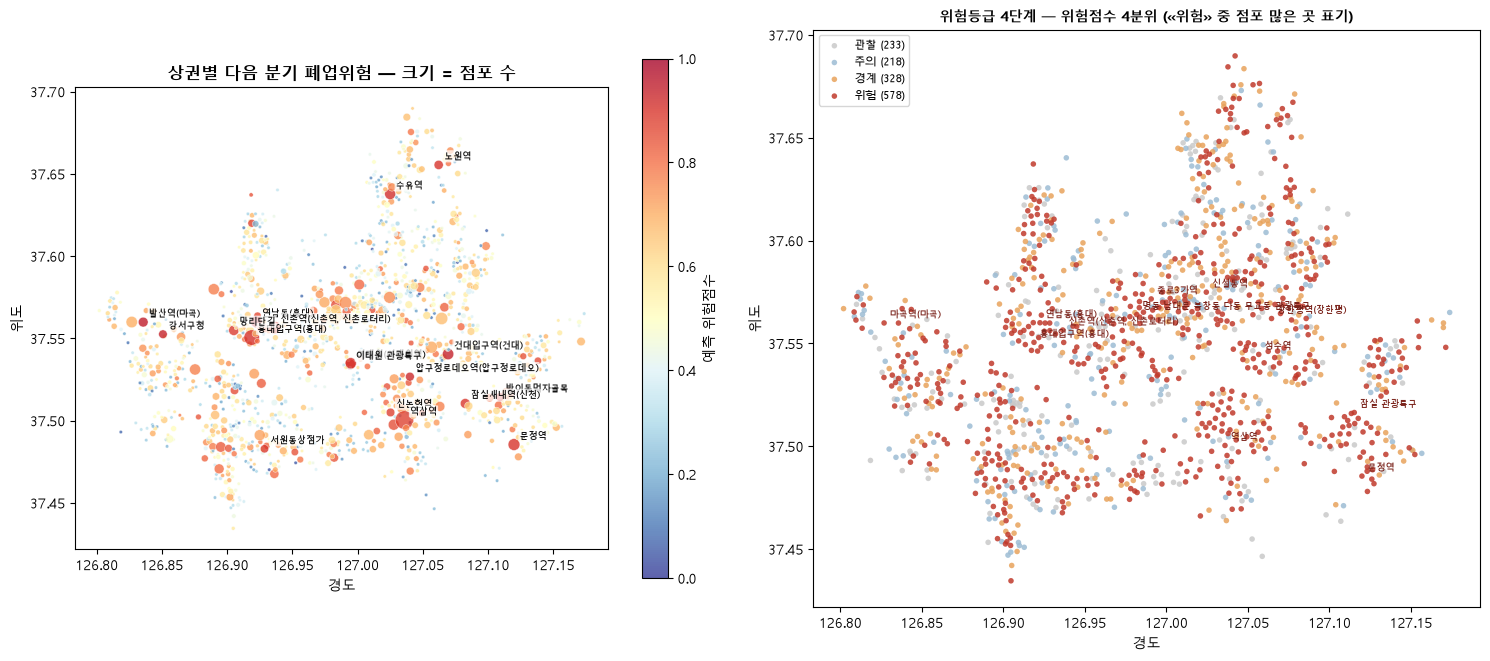

*그림 12*


왼쪽 그림에 위험점수 상위 18곳의 상권명을 표기함

500m 격자 678개 (칸 3개 이상) · 전체 격자 대비 74%

,gx,gy,칸수,평균위험,실제순감소율,점포합,자치구
0,370,902,10,0.817,0.500,925.0,강서구
1,410,923,10,0.714,0.500,728.0,노원구
2,385,900,10,0.695,0.500,1304.0,마포구
3,421,885,10,0.692,0.400,762.0,송파구
4,407,899,4,0.685,0.500,77.0,성동구
5,407,894,9,0.676,0.444,534.0,강남구
6,406,889,10,0.664,0.500,1020.0,강남구
7,404,888,10,0.660,0.400,1295.0,서초구
8,393,895,10,0.658,0.400,667.0,용산구
9,388,901,10,0.658,0.400,938.0,서대문구


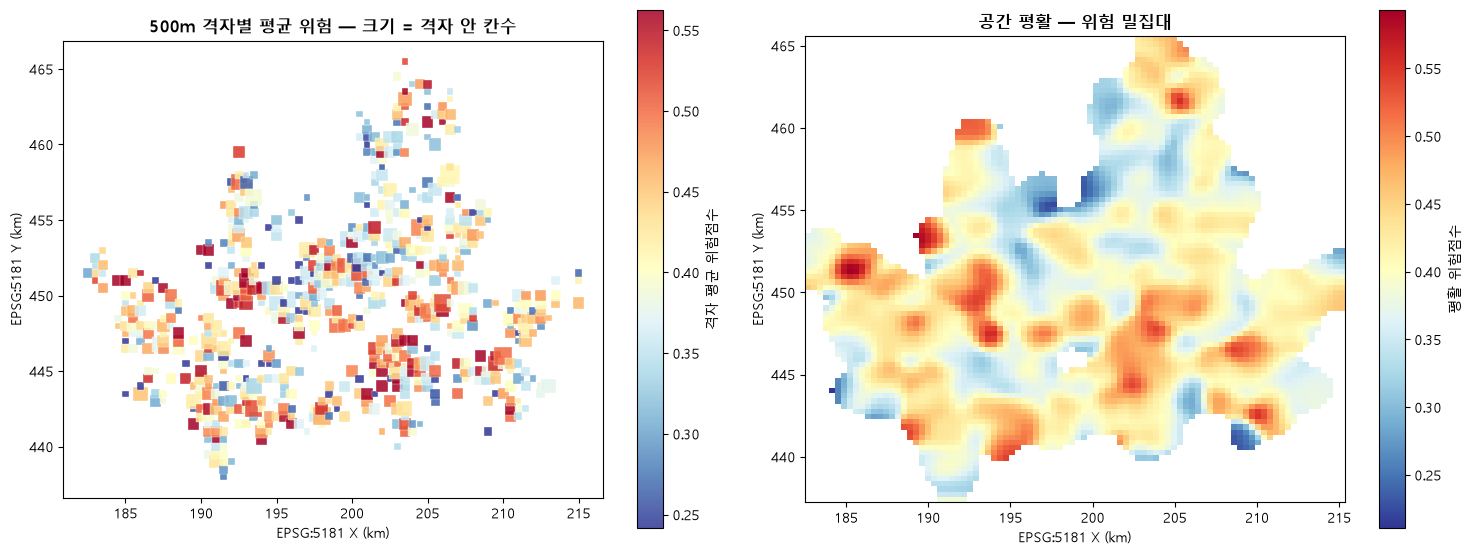

*그림 13*


역세권 상권(대리 거점) 191곳

,상권수,평균위험,실제순감소율,평균점포
역거리_구간,,,,
역세권 상권,191,0.623,0.414,53.419
0~250m,66,0.430,0.227,19.212
250~500m,370,0.475,0.273,21.095
500m~1km,519,0.468,0.295,21.383
1km 초과,211,0.434,0.294,18.569


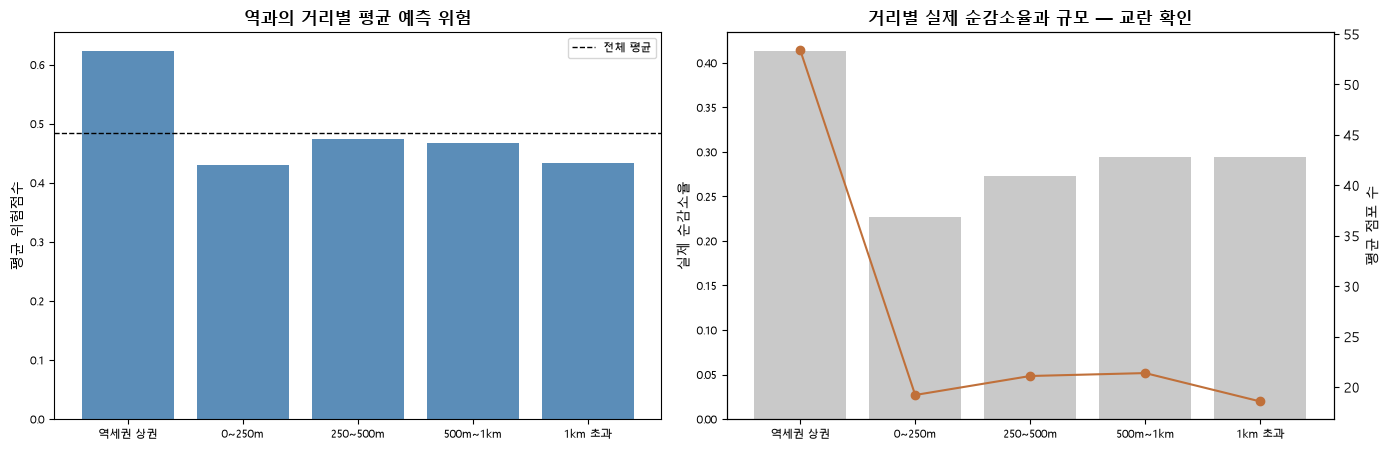

*그림 14*


역세권 상권 자체    평균 점포 53.4개 · 평균 위험 0.623
역 밖 구간 4개      평균 점포 18.6~21.4개 · 평균 위험 0.430~0.475

→ 결론: 거리 구배가 없음. 역 밖 네 구간의 위험이 0.46~0.50으로 사실상 평평하고,
   250m~1km 구간이 0~250m 구간보다 오히려 높아 순서도 맞지 않음.
   유일하게 두드러지는 것은 «역세권 상권 자체»인데 그 상권들의 평균 점포가
   2.4배 이상 크므로, 이것은 거리 효과가 아니라 규모 효과임.
   → 동심원 레이어는 «역과의 거리는 위험을 설명하지 못한다»는 음성 결과로 보고함.